# Stairs Up, Elevator Down 🛗
### "Markets take the stairs up and the elevator down." We timed both.

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Every trader has heard it: rallies are slow and orderly, crashes are sudden. We checked the
saying on three real tapes — the S&P 500 since 1990, the Nasdaq since 1999 and a century of US
market returns since 1926 — and found something more interesting than a yes or a no. The market
really is **lopsided in time**. But the fastest ten percent on the tape is not the fall from the
top. It is the bounce off the bottom.

> 📓 **This is the plain-language layer.** The statistics, the null worlds and the
> trading race are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it, from
> frozen, fingerprinted tapes (as-of 2022-11-30).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 160)
from stairs import data, strategy as st
UP, DOWN, GREY = "#2ea44f", "#c0392b", "#8b949e"

## The answer first 🛗

| Question | Answer |
|---|---|
| Is the index path lopsided in time? | **Yes** — run it backwards and it looks measurably different. |
| Do falls cover 10% faster than rises do? | **No — the reverse.** Losing 10% from a peak took ~18.5 sessions; regaining 10% off a low took ~13.4. |
| So where does the proverb come from? | Whole bull runs last a long time; whole sell-offs are short and steep. |
| What causes the lopsidedness? | Volatility jumps after a fall — and stays high right at the bottom. |
| Can you trade it? | Not as a holder: a "get out fast, get back in slowly" rule lost to buy-and-hold on daily data. |

## 1 · The claim

*"Stocks take the stairs up and the elevator down."* It's a line from trading floors and
financial TV, and it means more than "crashes happen". It says the **shape** of a market's path
has a direction: a slow, steady climb of small steps, then a drop that does in days what the
climb did in months. If you filmed the index and played the film backwards, you'd notice —
slow slides and sudden rockets.

That last sentence is the strongest form of the claim, and the one we test: the index path is
**not the same forwards and backwards**.

## 2 · So what?

If it's true, three things follow. Risk is lopsided — the next 10% down arrives faster than the
next 10% up, which matters for anyone with a stop-loss or a margin call. It explains why
**insurance against a fall (a put option) costs more** than a bet on a rise of the same size.
And it hints at a rule: if falls are fast and rises slow, you could step out quickly and step
back in at leisure, missing little of the climb.

## 3 · How we'd know

We decided the tests before running them:

- **Time it.** Cut the price path into rises and falls of at least 5%, 10% or 20%. For each, count
  the trading days it took to cover the first 10% (gaining from a low, or losing from a high).
- **Play it backwards.** A standard statistic (Ramsey & Rothman, 1996) is exactly zero for a path
  that looks the same in both directions, and flips sign when you reverse the tape.
- **Make fake markets.** Build worlds where we *know* the cause — with and without "volatility
  jumps after a fall" — and see which ones look like the real thing.
- **Trade it**, with a rule fixed in advance, after costs, against just holding.

*Mirage* would be: no difference forwards and backwards, or a difference no fake world can
explain, or a rule that only works before costs.

## 4 · The teardown

### 4.1 The film, forwards and backwards

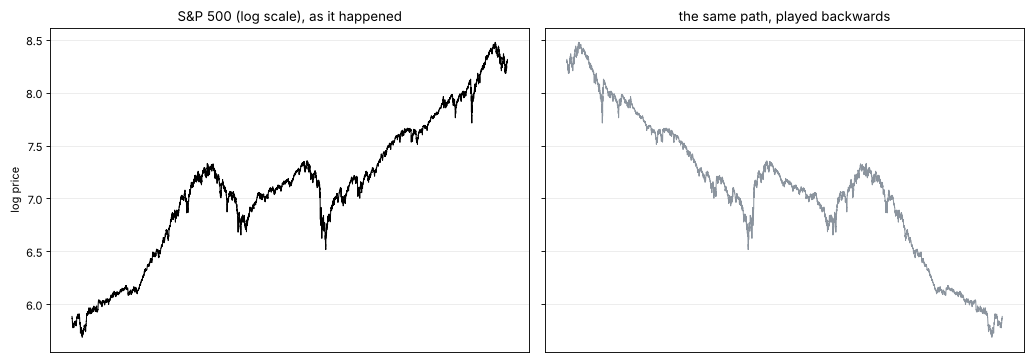

8,294 sessions, 1990-01-02 to 2022-11-30 (price index, no dividends)


In [2]:
sp = data.load_sp500()
lp = np.log(sp)
rev = pd.Series(lp.to_numpy()[::-1], index=lp.index)     # the same film, run backwards
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
ax[0].plot(lp.index, lp, color="k", lw=0.9)
ax[0].set_title("S&P 500 (log scale), as it happened")
ax[1].plot(rev.index, rev, color=GREY, lw=0.9)
ax[1].set_title("the same path, played backwards")
for a in ax:
    a.set_xticks([])
ax[0].set_ylabel("log price")
plt.tight_layout(); plt.show()
print(f"{len(sp):,} sessions, {sp.index[0].date()} to {sp.index[-1].date()} (price index, no dividends)")

Look at 2008 and 2020 on the left: cliff edges. On the right they become sudden rockets, and the
long climbs become long slides. Your eye already says the two films differ. The rest of this
notebook asks how much, in which direction, and why.

### 4.2 How long does it take to gain 10%, and to lose 10%?

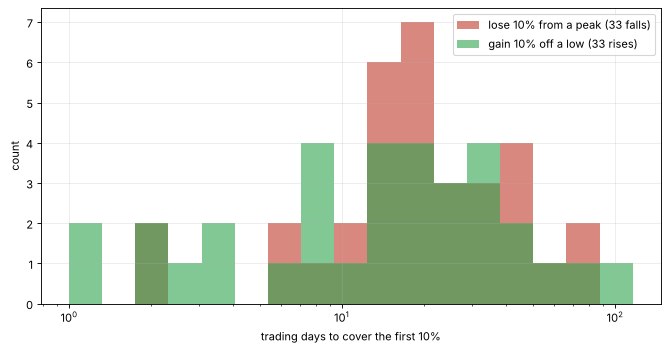

typical time to LOSE 10% from a peak: 18.5 sessions
typical time to GAIN 10% off a low:   13.4 sessions


In [3]:
L = st.legs(lp.to_numpy(), np.log1p(0.10))
up, dn = L[L["dir"] == 1]["fp_days"], L[L["dir"] == -1]["fp_days"]
fig, ax = plt.subplots(figsize=(10, 4.8))
bins = np.logspace(0, np.log10(max(up.max(), dn.max()) + 1), 18)
ax.hist(dn, bins=bins, alpha=0.6, color=DOWN, label=f"lose 10% from a peak ({len(dn)} falls)")
ax.hist(up, bins=bins, alpha=0.6, color=UP, label=f"gain 10% off a low ({len(up)} rises)")
ax.set_xscale("log"); ax.set_xlabel("trading days to cover the first 10%")
ax.set_ylabel("count"); ax.legend()
plt.show()
gm = lambda s: float(np.exp(np.log(s).mean()))
print(f"typical time to LOSE 10% from a peak: {gm(dn):.1f} sessions")
print(f"typical time to GAIN 10% off a low:   {gm(up):.1f} sessions")

Here is the surprise. Measured like-for-like — the same 10%, timed from the turning point — the
**rebound is faster than the fall**: about 13.4 sessions to gain it against
18.5 to lose it. The same holds at 5% and 20%, on the Nasdaq, and on a century of
monthly data. Compared with fake markets that have the same day sizes in random directions, the
real tape sits at the "rebounds are fast" end (only 0.010 of fake worlds go that
far).

> 🔬 **For the quants.** Elevator ratio = geometric-mean up time ÷ down time =
> 0.73× at 10%. Sign-flip Monte Carlo null (keeps |r_t|, drift and vol clustering):
> one-sided p = 0.995 in the elevator direction, 0.010 in the reverse one.

### 4.3 Then where does the proverb come from?

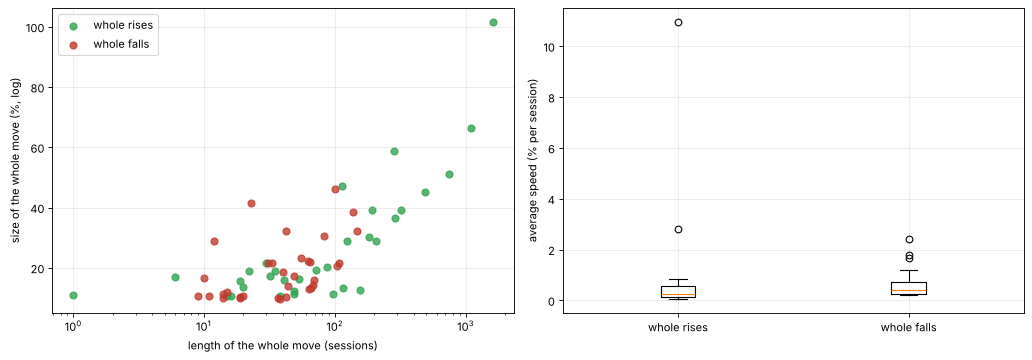

       dur_days  speed
dir                   
falls    42.000  0.425
rises    79.500  0.241


In [4]:
full = L.dropna(subset=["dur_days"]).copy()
full["speed"] = full["move"].abs() / full["dur_days"] * 100
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for d, c, lab in ((1, UP, "whole rises"), (-1, DOWN, "whole falls")):
    f = full[full["dir"] == d]
    ax[0].scatter(f["dur_days"], f["move"].abs() * 100, color=c, s=40, alpha=0.8, label=lab)
ax[0].set_xscale("log"); ax[0].set_xlabel("length of the whole move (sessions)")
ax[0].set_ylabel("size of the whole move (%, log)"); ax[0].legend()
ax[1].boxplot([full[full["dir"] == 1]["speed"], full[full["dir"] == -1]["speed"]])
ax[1].set_xticks([1, 2]); ax[1].set_xticklabels(["whole rises", "whole falls"])
ax[1].set_ylabel("average speed (% per session)")
plt.tight_layout(); plt.show()
print(full.groupby("dir")[["dur_days", "speed"]].median().rename(index={1: "rises", -1: "falls"}))

The proverb is about the **whole** move. Bull runs go on for months and years, so their
*average* pace is slow; sell-offs end sooner, so their average pace is steep — about
1.76× faster per day. That is the stairs and the elevator people remember. But the
first 10% of a bounce off a bottom is quicker than the first 10% of a slide off a top.

### 4.4 Played backwards, the numbers flip

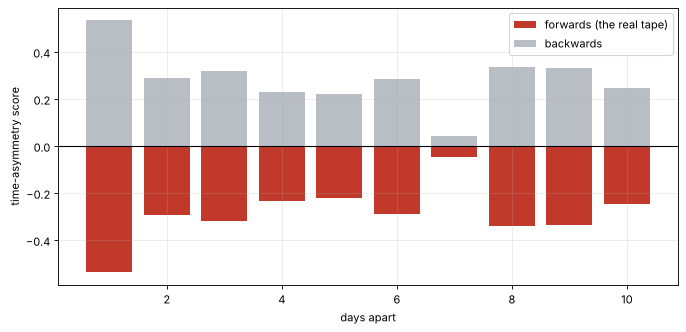

total score forwards -2.85, backwards +2.85


In [5]:
r = st.log_returns(sp).to_numpy()
tr = st.tr_stats(r, K=10, n_boot=200)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(tr["per_lag"].index, tr["per_lag"]["tr"], color=DOWN, label="forwards (the real tape)")
x_rev = st.standardise(r)[::-1]
rev_lag = st.tr_products(x_rev, 10).mean(axis=0)
ax.bar(tr["per_lag"].index, rev_lag, color=GREY, alpha=0.6, label="backwards")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("days apart"); ax.set_ylabel("time-asymmetry score")
ax.legend(); plt.show()
print(f"total score forwards {tr['tr_sum']:+.2f}, backwards {tr['tr_sum_reversed']:+.2f}")

A path that looked the same both ways would score zero on every bar. The real tape scores
negative on all ten — and exactly the mirror image when reversed. The odds of that by luck are
tiny: the robust t-statistic is -3.39 (the desk's bar is 2), and the Nasdaq says the
same (-3.63). So the market **is** lopsided in time. Just not in the way the proverb
says.

### 4.5 What makes it lopsided? Build fake markets and see

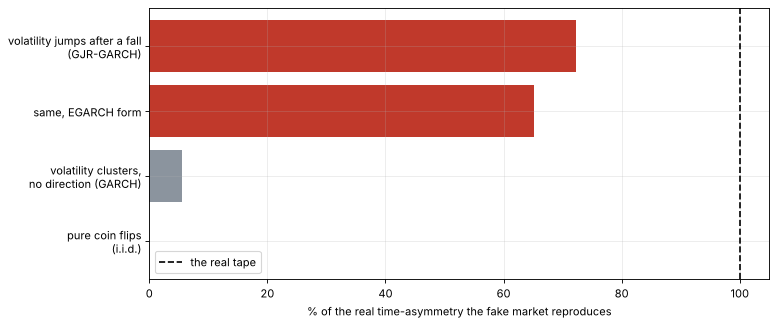

In [6]:
mech = [("volatility jumps after a fall\n(GJR-GARCH)", 0.723), ("same, EGARCH form", 0.651),
        ("volatility clusters,\nno direction (GARCH)", 0.055), ("pure coin flips\n(i.i.d.)", 0.0)]
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.barh([m[0] for m in mech][::-1], [100 * m[1] for m in mech][::-1],
        color=[GREY, GREY, DOWN, DOWN])
ax.axvline(100, color="k", ls="--", lw=1.5, label="the real tape")
ax.set_xlabel("% of the real time-asymmetry the fake market reproduces"); ax.legend()
plt.show()

*(Shares quoted from the simulation in `docs/results.md`; the quants notebook re-runs it.)*

Only worlds where **volatility rises more after a fall than after a rise** — the "leverage
effect" — look like the real thing: they reproduce about 72% of the asymmetry
score, and they even get the fast-rebound surprise right. A world where calm and storm come in
clusters but don't care about direction reproduces none of it (6%); neither
do coin flips. The bottom of a sell-off is where volatility peaks, and high volatility moves
prices quickly — in both directions. That's why the first 10% off the low is fast.

## 5 · The verdict

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

**Signal — Mixed.** The index path is genuinely irreversible in time (t = -3.39),
caused by volatility reacting to falls. But the literal saying — the same distance covered faster
down than up — runs backwards on every tape we have. The verdict splits by which reading of the
proverb you take, and the desk stamps that split as Mixed.

**Tradability — Mirage.** See below.

## 6 · Could you trade it?

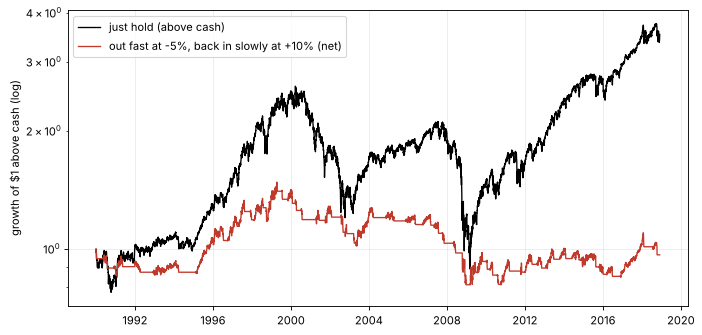

Sharpe above cash: rule 0.04 vs hold 0.34; time invested 51%


In [7]:
ff = data.load_ff_market()
sp_t = sp[sp.index <= pd.Timestamp(data.FF_AS_OF)]
rf = data.daily_rf(sp_t.index, ff)
sig = st.zigzag_rule(sp_t, 0.05, 0.10)
bt = st.backtest(sp_t, rf, sig, cost=0.0005, lag=1)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot((1 + bt["ex_bh"]).cumprod(), color="k", lw=1.2, label="just hold (above cash)")
ax.plot((1 + bt["ex_net"]).cumprod(), color=DOWN, lw=1.2,
        label="out fast at -5%, back in slowly at +10% (net)")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 above cash (log)"); ax.legend()
plt.show()
print(f"Sharpe above cash: rule {bt['sharpe_net']:.2f} vs hold {bt['sharpe_bh']:.2f}; "
      f"time invested {bt['time_in']:.0%}")

We fixed the rule before looking: **get out after a 5% drop, get back in only after a 10%
rebound** — fast out because the elevator is fast, slow in because the stairs are slow. One day
of delay, realistic costs, cash earning T-bill interest while out. On the S&P 500 it scored a
Sharpe of 0.04 against 0.34 for just holding, and it lost on the
Nasdaq too — even though these price-only tapes leave out dividends, which *helps* a rule that
sits in cash. The reason is the study's own finding: the sharpest rallies start right at the
lows, exactly when a "wait for confirmation" rule is sitting out.

On a century of monthly data the rule did beat holding (+0.14 Sharpe), but almost all of
that is sitting out 1929-32, and a plain symmetric 10%-in/10%-out rule did as well — so the
stairs-and-elevator shape isn't what earned it. What the rule really buys is a smaller worst
drawdown: insurance, paid for in return. **Mirage.**

> 🔬 **For the quants.** Paired block-bootstrap of the net excess-Sharpe difference,
> rule − hold: S&P 500 -0.30, Nasdaq -0.22, Fama-French 1926-2018 +0.14
> (p = 0.03), 1946-2018 +0.08 (p = 0.23).

## 7 · Going further

- **Options.** The desk's frozen tapes carry no option prices. The natural next step is to show
  that the irreversibility measured here lines up with the steepness of the index put skew.
- **Single stocks.** Individual shares are often *positively* skewed. Are they still
  irreversible in the leverage direction?
- **Intraday.** Does the fast-rebound effect hold at the hourly scale, where the 2010 and 2015
  flash events live?

Fork it, change the thresholds in `stairs/strategy.py`, and send a PR.